#**1. Introduction**

**Retail Investor Behavior on Robinhood**

This analysis explores how retail investors behave on Robinhood, focusing on trends, correlations, and key insights. By using historical data and visualizations, we aim to uncover patterns in user activity and market dynamics.

**Key Objectives**
1. Analyze trends in retail investor activity.
2. Explore correlations between market events and investor behavior.
3. Identify key moments or patterns influencing activity.

**Important Note on Data and Paths**

- The data used in this analysis **is not included** in this repository due to confidentiality.
- File paths in the notebook (e.g., `/content/drive/...`) are specific to the environment in which the analysis was performed (e.g., Google Colab or local setup).
- To replicate the analysis, replace the file paths with paths to **your local or cloud-based dataset**.


# **2. Data Loading and Preparation**


##**a. Imports and Data Loading**



1. Here, we import essential libraries for data manipulation, visualization, and analysis:
- `pandas` and `numpy`: For data handling and numerical operations.
- `matplotlib`: For creating visualizations.
- TensorFlow: Used if required for advanced modeling.

2. The dataset is sourced from Robinhood Retail Investor Data. It includes:
- User activity metrics.
- Stock trading patterns.
- Market performance indicators.



In [ ]:
# Importing the necessary libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
# plt.style.use('ggplot')

import os
import time

import tensorflow as tf

from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
os.getcwd()

'/content'

In [ ]:
images_path = '/content/drive/My Drive/DSO_545_Fall_2024/Images/'

# Setting up the data path
data_path = '/content/drive/My Drive/DSO_545_Fall_2024/06_Robinhood_and_Retail_Investor_Behavior_I/Data/'

In [ ]:
# To list the content of the directory specified
os.listdir(data_path)

['GE.csv',
 'AAPL.csv',
 'AAL.csv',
 'MSFT.csv',
 'F.csv',
 'AA.csv',
 'Robinhood_Data.zip',
 'popularity_export',
 'crsp',
 'Options_Data',
 'avg_daily_rh_user_holding.gsheet',
 'avg_daily_rh_user_holding.csv',
 'daily_ret_of_top_stocks.csv']

In [ ]:
# Measures and prints the execution time of the cell
%%time
tickers = os.path.join(data_path, 'popularity_export')

# Sorted Sorts the list of names of files and dictionaries in ascending order
# os.listdir lists all the contents of the specified directory
len(sorted(os.listdir(tickers)))

CPU times: user 14.4 ms, sys: 2.76 ms, total: 17.1 ms
Wall time: 1.11 s


8642

In [ ]:
# Read the CSV file
tickers = os.path.join(data_path, 'popularity_export')
data = pd.read_csv(os.path.join(tickers, 'A.csv'))

# Display the first five rows
data.head()

# Display the last five rows
data.tail()

,timestamp,users_holding
19738,2020-08-13 15:59:22,1634
19739,2020-08-13 16:57:18,1634
19740,2020-08-13 20:58:16,1642
19741,2020-08-13 21:54:16,1642
19742,2020-08-13 23:00:48,1642


##**b. Understanding the Data Structure**



In [ ]:
# Check the shape of the DataFrame
data.shape

# Display information about the DataFrame
data.info()

# Generate summary statistics
data.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19743 entries, 0 to 19742
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   timestamp      19743 non-null  object
 1   users_holding  19743 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 308.6+ KB


,users_holding
count,19743.000000
mean,1069.187611
std,321.218647
min,576.000000
25%,716.000000
50%,1161.000000
75%,1356.000000
max,1642.000000


##**c. Convert Timestamps and Aggregate Data**

In [ ]:
# Convert timestamp to datetime
data['timestamp'] = pd.to_datetime(data['timestamp'])

# Extract date from timestamp
data['date'] = pd.to_datetime(data['timestamp'].dt.date)

# Group by date and compute mean
daily_mean = data.groupby('date').mean()
print("Daily mean of users holding:")
display(daily_mean)

Daily mean of users holding:


,timestamp,users_holding
date,,
2018-05-02,2018-05-02 05:49:18.500000000,590.000000
2018-05-03,2018-05-03 14:04:05.210526464,586.473684
2018-05-04,2018-05-04 13:34:33.458333440,587.458333
2018-05-05,2018-05-05 12:15:58.875000064,588.000000
2018-05-06,2018-05-06 12:15:58.708333312,588.000000
...,...,...
2020-08-09,2020-08-09 12:19:24.333333248,1616.000000
2020-08-10,2020-08-10 12:19:14.583333120,1619.208333
2020-08-11,2020-08-11 12:19:14.500000000,1625.500000


##**d. Using Resampling for Time-Based Aggregations**

In [ ]:
# Set date as index and sort
data.set_index('date', inplace=True)
data.sort_index(inplace=True)

# Resample data daily and compute mean
daily_resampled = data.resample('D').mean()
print("Daily resampled mean:")
display(daily_resampled)

Daily resampled mean:


,timestamp,users_holding
date,,
2018-05-02,2018-05-02 05:49:18.500000000,590.000000
2018-05-03,2018-05-03 14:04:05.210526464,586.473684
2018-05-04,2018-05-04 13:34:33.458333440,587.458333
2018-05-05,2018-05-05 12:15:58.875000064,588.000000
2018-05-06,2018-05-06 12:15:58.708333312,588.000000
...,...,...
2020-08-09,2020-08-09 12:19:24.333333248,1616.000000
2020-08-10,2020-08-10 12:19:14.583333120,1619.208333
2020-08-11,2020-08-11 12:19:14.500000000,1625.500000


##**e. Handling Missing Data**

In [ ]:
# Find missing dates
dates_in_resample = daily_resampled.index.difference(daily_mean.index)

# Display data for missing dates
print("Data for missing dates:")
display(daily_resampled.loc[dates_in_resample,:])

# Drop rows with missing data
clean_data = daily_resampled.dropna()
print("\nData after dropping missing values:")
display(clean_data)

Data for missing dates:


,timestamp,users_holding
date,,
2018-08-09,NaT,NaN
2019-01-24,NaT,NaN
2019-01-25,NaT,NaN
2019-01-26,NaT,NaN
2019-01-27,NaT,NaN
2019-01-28,NaT,NaN
2019-01-29,NaT,NaN
2019-03-03,NaT,NaN
2020-01-07,NaT,NaN



Data after dropping missing values:


,timestamp,users_holding
date,,
2018-05-02,2018-05-02 05:49:18.500000000,590.000000
2018-05-03,2018-05-03 14:04:05.210526464,586.473684
2018-05-04,2018-05-04 13:34:33.458333440,587.458333
2018-05-05,2018-05-05 12:15:58.875000064,588.000000
2018-05-06,2018-05-06 12:15:58.708333312,588.000000
...,...,...
2020-08-09,2020-08-09 12:19:24.333333248,1616.000000
2020-08-10,2020-08-10 12:19:14.583333120,1619.208333
2020-08-11,2020-08-11 12:19:14.500000000,1625.500000


##**f. Plotting the Data**

The following visualization examines changes in retail investor activity over time. By analyzing spikes and drops, we can infer the influence of market events on investor behavior.


<Axes: xlabel='date'>

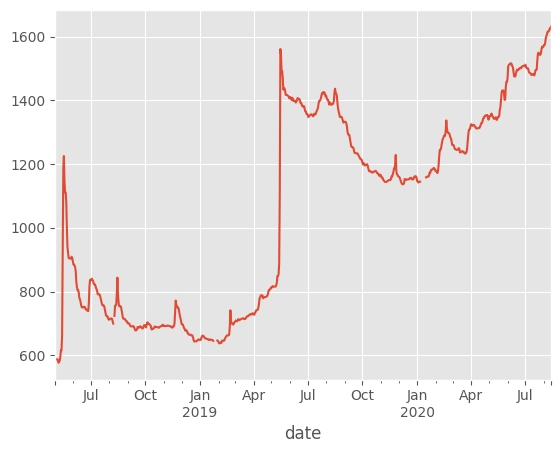

In [ ]:
# Plotting the daily average of users holding the stock
daily_resampled['users_holding'].plot()

**Key Insights:**
- Significant spikes during events like the GameStop short squeeze.
- Activity tends to peak during high-volatility periods.


#**3. Exploratory Data Analysis (EDA)**

Here, we analyze trends and patterns in retail investor activity, including:
1. Time-based activity trends.
2. Popular stocks traded by retail investors.
3. Correlations between market volatility and user behavior.


## **a. Data Processing Using Keyword Arguments**

In [ ]:
# Step 1: Define a list of tickers
tickers = os.path.join(data_path, 'popularity_export')

# Step 2: Create an empty list to hold DataFrames for each ticker
user_holdings = []

# Start timing the operation
start = time.time()

# Step 3: Loop over all CSV files in the directory
for ticker_file in sorted(os.listdir(tickers)):
    # Step 4: Extract the ticker symbol by removing ".csv"
    ticker_file = ticker_file[:-4]

    # Step 5: Read in the CSV file with appropriate parameters
    data = pd.read_csv(os.path.join(tickers, f'{ticker_file}.csv'), parse_dates=['timestamp'], index_col=0)

    # Step 6: Resample data to daily frequency, taking the mean
    data = data.resample('D').mean()

    # Step 7: Rename columns for clarity
    data.rename(columns={'users_holding': f'{ticker_file}_avg_users_holding'}, inplace=True)

    # Append DataFrame to the list
    user_holdings.append(data)

# Concatenate all DataFrames along the columns
daily_holdings_of_all_stocks = pd.concat(user_holdings, axis=1)
daily_holdings_of_all_stocks.index.name = 'Date'

# End timing the operation
end = time.time()
print(f'The code takes {(end - start) / 60:.2f} minutes to run.')

# Display the combined DataFrame
daily_holdings_of_all_stocks.head()

The code takes 8.14 minutes to run.


,A_avg_users_holding,AA_avg_users_holding,AAAU_avg_users_holding,AACAY_avg_users_holding,AACG_avg_users_holding,AADR_avg_users_holding,AAGIY_avg_users_holding,AAL_avg_users_holding,AAMC_avg_users_holding,AAME_avg_users_holding,...,ZTS_avg_users_holding,ZUMZ_avg_users_holding,ZUO_avg_users_holding,ZURVY_avg_users_holding,ZVO_avg_users_holding,ZYME_avg_users_holding,ZYNE_avg_users_holding,ZYXI_avg_users_holding,_OUT_avg_users_holding,_PRN_avg_users_holding
Date,,,,,,,,,,,,,,,,,,,,,
2018-05-02,590.000000,NaN,NaN,NaN,55.000000,NaN,NaN,3755.000000,NaN,119.000000,...,588.000000,248.000000,539.000000,NaN,NaN,NaN,6127.000000,NaN,158.000000,12.0
2018-05-03,586.473684,NaN,NaN,NaN,55.473684,NaN,NaN,3778.368421,NaN,118.315789,...,610.421053,250.052632,544.423077,NaN,NaN,NaN,6137.052632,NaN,156.263158,12.0
2018-05-04,587.458333,NaN,NaN,NaN,55.458333,NaN,NaN,3762.750000,NaN,119.000000,...,608.083333,249.166667,547.739130,NaN,NaN,NaN,6145.416667,NaN,154.000000,12.0
2018-05-05,588.000000,NaN,NaN,NaN,56.000000,NaN,NaN,3748.000000,NaN,119.000000,...,607.000000,247.000000,550.000000,NaN,NaN,NaN,6140.000000,NaN,154.000000,12.0
2018-05-06,588.000000,NaN,NaN,NaN,56.000000,NaN,NaN,3748.000000,NaN,119.000000,...,607.000000,247.000000,550.000000,NaN,NaN,NaN,6140.000000,NaN,154.000000,12.0


## **b. Save Processed Data to CSV**

In [ ]:
# Save the concatenated DataFrame to a CSV file
#daily_holdings_of_all_stocks.to_csv(os.path.join(data_path, 'avg_daily_rh_user_holdings.csv'))

# Ensure the 'Date' column is set as the index and sorted
#daily_holdings_of_all_stocks['Date'] = pd.to_datetime(daily_holdings_of_all_stocks['Date'])
# daily_holdings_of_all_stocks.set_index('Date', inplace=True)
# daily_holdings_of_all_stocks.sort_index(inplace=True)

# Display the final DataFrame
daily_holdings_of_all_stocks

,A_avg_users_holding,AA_avg_users_holding,AAAU_avg_users_holding,AACAY_avg_users_holding,AACG_avg_users_holding,AADR_avg_users_holding,AAGIY_avg_users_holding,AAL_avg_users_holding,AAMC_avg_users_holding,AAME_avg_users_holding,...,ZTS_avg_users_holding,ZUMZ_avg_users_holding,ZUO_avg_users_holding,ZURVY_avg_users_holding,ZVO_avg_users_holding,ZYME_avg_users_holding,ZYNE_avg_users_holding,ZYXI_avg_users_holding,_OUT_avg_users_holding,_PRN_avg_users_holding
Date,,,,,,,,,,,,,,,,,,,,,
2018-05-02,590.000000,NaN,NaN,NaN,55.000000,NaN,NaN,3755.000000,NaN,119.000000,...,588.000000,248.000000,539.000000,NaN,NaN,NaN,6127.000000,NaN,158.000000,12.000000
2018-05-03,586.473684,NaN,NaN,NaN,55.473684,NaN,NaN,3778.368421,NaN,118.315789,...,610.421053,250.052632,544.423077,NaN,NaN,NaN,6137.052632,NaN,156.263158,12.000000
2018-05-04,587.458333,NaN,NaN,NaN,55.458333,NaN,NaN,3762.750000,NaN,119.000000,...,608.083333,249.166667,547.739130,NaN,NaN,NaN,6145.416667,NaN,154.000000,12.000000
2018-05-05,588.000000,NaN,NaN,NaN,56.000000,NaN,NaN,3748.000000,NaN,119.000000,...,607.000000,247.000000,550.000000,NaN,NaN,NaN,6140.000000,NaN,154.000000,12.000000
2018-05-06,588.000000,NaN,NaN,NaN,56.000000,NaN,NaN,3748.000000,NaN,119.000000,...,607.000000,247.000000,550.000000,NaN,NaN,NaN,6140.000000,NaN,154.000000,12.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2020-08-09,1616.000000,5678.000000,1727.000000,361.000000,1664.000000,13.0,334.000000,641785.000000,89.000000,260.000000,...,2735.000000,494.000000,6202.000000,231.000000,5806.000000,674.000000,32097.000000,3192.000000,2021.000000,23.000000
2020-08-10,1619.208333,5668.750000,1735.041667,360.125000,1658.791667,13.0,334.166667,640821.833333,88.375000,259.333333,...,2736.208333,498.041667,6224.458333,230.333333,5759.166667,673.208333,32060.833333,3186.916667,2017.041667,23.416667
2020-08-11,1625.500000,5683.166667,1732.833333,358.583333,1647.458333,13.0,334.625000,639770.583333,87.250000,255.958333,...,2732.416667,502.666667,6308.166667,228.416667,5635.833333,674.875000,31939.875000,3170.041667,2002.500000,24.000000


## **c. Analysis of Top 6 Stocks**

Here, we analyze the most popular stocks among retail investors. This helps us understand:
- Which industries dominate interest.
- The impact of media and trends on trading patterns.

In [ ]:
# To get a list of these top 6 stocks at the end of our sample, we need to slice the end of our sample and compute the order statistics of the cross-section of average daily user holdings

# STEP 1: Slice the last day of the sample using iloc

# STEP 2: Drop any stocks that are not being held by a Robinhood user at that point in the sample

# STEP 3: Sort the data from top to bottom according to average user holdings

# STEP 4: Slice the top 6 stocks from the sorted dataframe



**Slicing the Last Day of the Sample**

In [ ]:
# Slice the last day of the sample
last_day_data = daily_holdings_of_all_stocks.iloc[-1, :]  # Take the last row

# Drop any stocks with NaN values
last_day_data = last_day_data.dropna()

# Sort data from top to bottom based on user holdings
sorted_data = last_day_data.sort_values(ascending=False)

# Select the top 6 stocks with the highest average user holdings
top_6_stocks = sorted_data.iloc[:6] # This is a series, hence it only needs a row slicer
top_6_stocks

# Simplified method
# top_6_stocks =daily_holdings_of_all_stocks.iloc[-1,:].nlargest(6)

,2020-08-13
F_avg_users_holding,913120.65
GE_avg_users_holding,857936.80
AAPL_avg_users_holding,720905.50
MSFT_avg_users_holding,654239.60
AAL_avg_users_holding,638793.60
DIS_avg_users_holding,598965.40


**Slicing the Data for These Stocks**

In [ ]:
# Get the names of the top 6 stocks
top_6_stocks.index

# Extract the daily holdings for the top 6 stocks
daily_holdings_of_top_6_stocks = daily_holdings_of_all_stocks.loc[:, top_6_stocks.index]
daily_holdings_of_top_6_stocks

,F_avg_users_holding,GE_avg_users_holding,AAPL_avg_users_holding,MSFT_avg_users_holding,AAL_avg_users_holding,DIS_avg_users_holding
Date,,,,,,
2018-05-02,131071.000000,134735.000000,150785.000000,112514.000000,3755.000000,59936.000000
2018-05-03,131226.842105,134576.105263,144779.052632,113103.631579,3778.368421,60186.421053
2018-05-04,130959.583333,134573.125000,142690.875000,112515.083333,3762.750000,60319.166667
2018-05-05,130621.666667,134446.500000,141428.000000,112007.000000,3748.000000,60117.666667
2018-05-06,130623.000000,134447.125000,141436.916667,112007.000000,3748.000000,60119.000000
...,...,...,...,...,...,...
2020-08-09,920470.000000,860703.000000,683300.000000,643729.000000,641785.000000,603808.000000
2020-08-10,918952.750000,860856.458333,688717.500000,645807.500000,640821.833333,603214.458333
2020-08-11,915765.083333,860064.458333,701134.500000,651363.750000,639770.583333,601230.500000


In [ ]:
daily_holdings_of_top_6_stocks = daily_holdings_of_all_stocks.loc[:,top_6_stocks.index]
daily_holdings_of_top_6_stocks

,F_avg_users_holding,GE_avg_users_holding,AAPL_avg_users_holding,MSFT_avg_users_holding,AAL_avg_users_holding,DIS_avg_users_holding
Date,,,,,,
2018-05-02,131071.000000,134735.000000,150785.000000,112514.000000,3755.000000,59936.000000
2018-05-03,131226.842105,134576.105263,144779.052632,113103.631579,3778.368421,60186.421053
2018-05-04,130959.583333,134573.125000,142690.875000,112515.083333,3762.750000,60319.166667
2018-05-05,130621.666667,134446.500000,141428.000000,112007.000000,3748.000000,60117.666667
2018-05-06,130623.000000,134447.125000,141436.916667,112007.000000,3748.000000,60119.000000
...,...,...,...,...,...,...
2020-08-09,920470.000000,860703.000000,683300.000000,643729.000000,641785.000000,603808.000000
2020-08-10,918952.750000,860856.458333,688717.500000,645807.500000,640821.833333,603214.458333
2020-08-11,915765.083333,860064.458333,701134.500000,651363.750000,639770.583333,601230.500000


##**d. Analyzing Robinhood User Activity with Matplotlib API**

Here, we visualize the stock data with line plots.

**Method 1: Creating a Figure Object and Adding Multiple Plots**

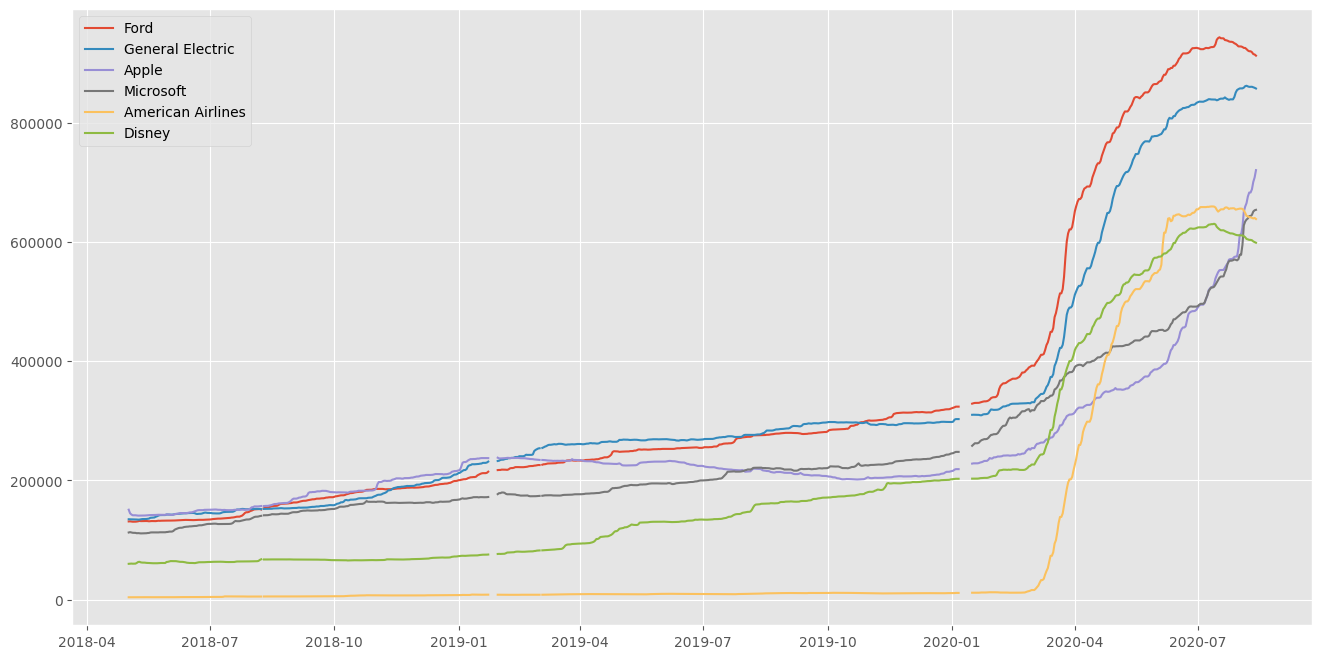

In [ ]:
# Set the plotting style to 'ggplot' for a more polished look
plt.style.use('ggplot')

# Instantiate a figure object with specific size
fig = plt.figure(figsize=(16, 8))

# Add a single axes to the figure
ax = fig.add_subplot(1, 1, 1)

# Plotting the time series for the top 6 stocks
ax.plot(data_ford, label='Ford')
ax.plot(data_GE, label='General Electric')
ax.plot(data_Apple, label='Apple')
ax.plot(data_Microsoft, label='Microsoft')
ax.plot(data_American_Airlines, label='American Airlines')
ax.plot(data_Disney, label='Disney')

# Display the legend on the plot
plt.legend(loc='best')

**Method 2: Using the subplots method**

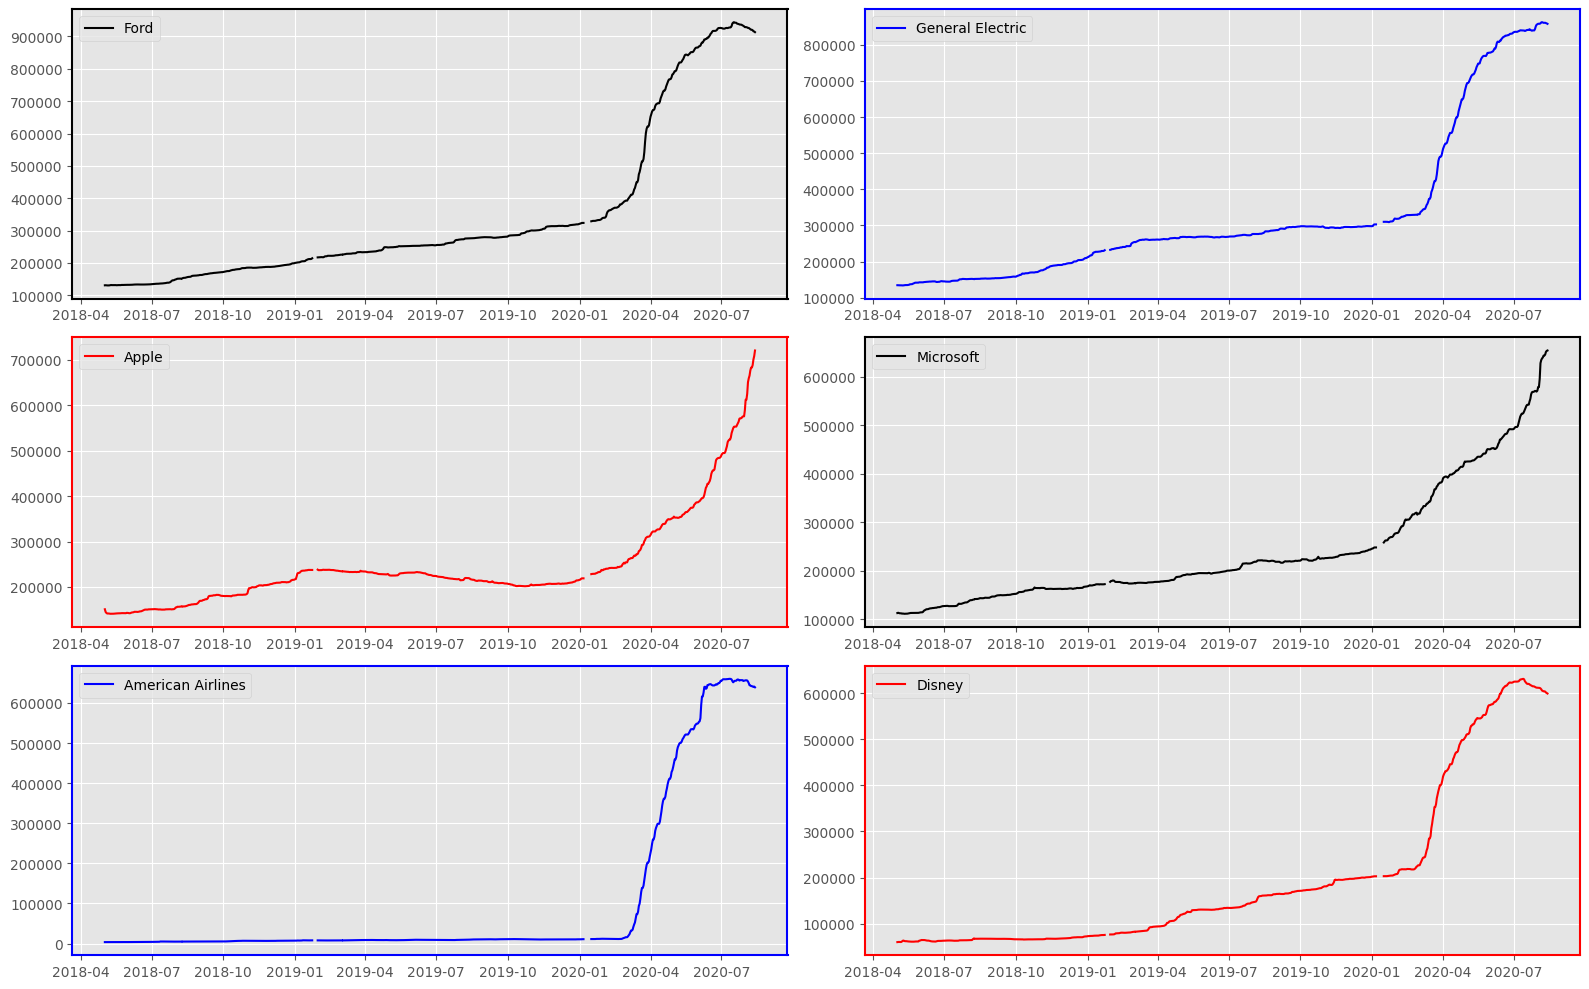

In [ ]:
import matplotlib.pyplot as plt

# Create a list of edge colors for each subplot
edge_colors = ['black', 'blue', 'red', 'black', 'blue', 'red']

# Creating subplots
fig, axs = plt.subplots(nrows=3, ncols=2, figsize=(16, 10))

# Adding plots to each subplot
axs[0, 0].plot(data_ford, label='Ford', color='black')
axs[0, 0].legend(loc='best')

axs[0, 1].plot(data_GE, label='General Electric', color='blue')
axs[0, 1].legend(loc='best')

axs[1, 0].plot(data_Apple, label='Apple', color='red')
axs[1, 0].legend(loc='best')

axs[1, 1].plot(data_Microsoft, label='Microsoft', color='black')
axs[1, 1].legend(loc='best')

axs[2, 0].plot(data_American_Airlines, label='American Airlines', color='blue')
axs[2, 0].legend(loc='best')

axs[2, 1].plot(data_Disney, label='Disney', color='red')
axs[2, 1].legend(loc='best')

# Loop through each subplot to customize spines
for ax, color in zip(axs.flatten(), edge_colors):
    # Set the color and width of the four spines
    for spine in ax.spines.values():
        spine.set_edgecolor(color)
        spine.set_linewidth(1.5)  # Optional: Set the width of the edge

# Adjust layout
plt.tight_layout()
plt.show()

**Key Insights From Visualization:**
- Tech and high-volatility stocks dominate the top-traded list.
- Retail investors favor stocks with heavy media coverage.


##**e. Analyzing Stock Performance: Percentage Changes and Holdings**

This section analyzes changes in holdings and trading percentages to uncover patterns in retail investor behavior:
1. Identify periods of significant trading activity (e.g., spikes during high-volatility events).
2. Highlight stocks with consistent popularity and increased holdings, often influenced by external factors like media coverage.



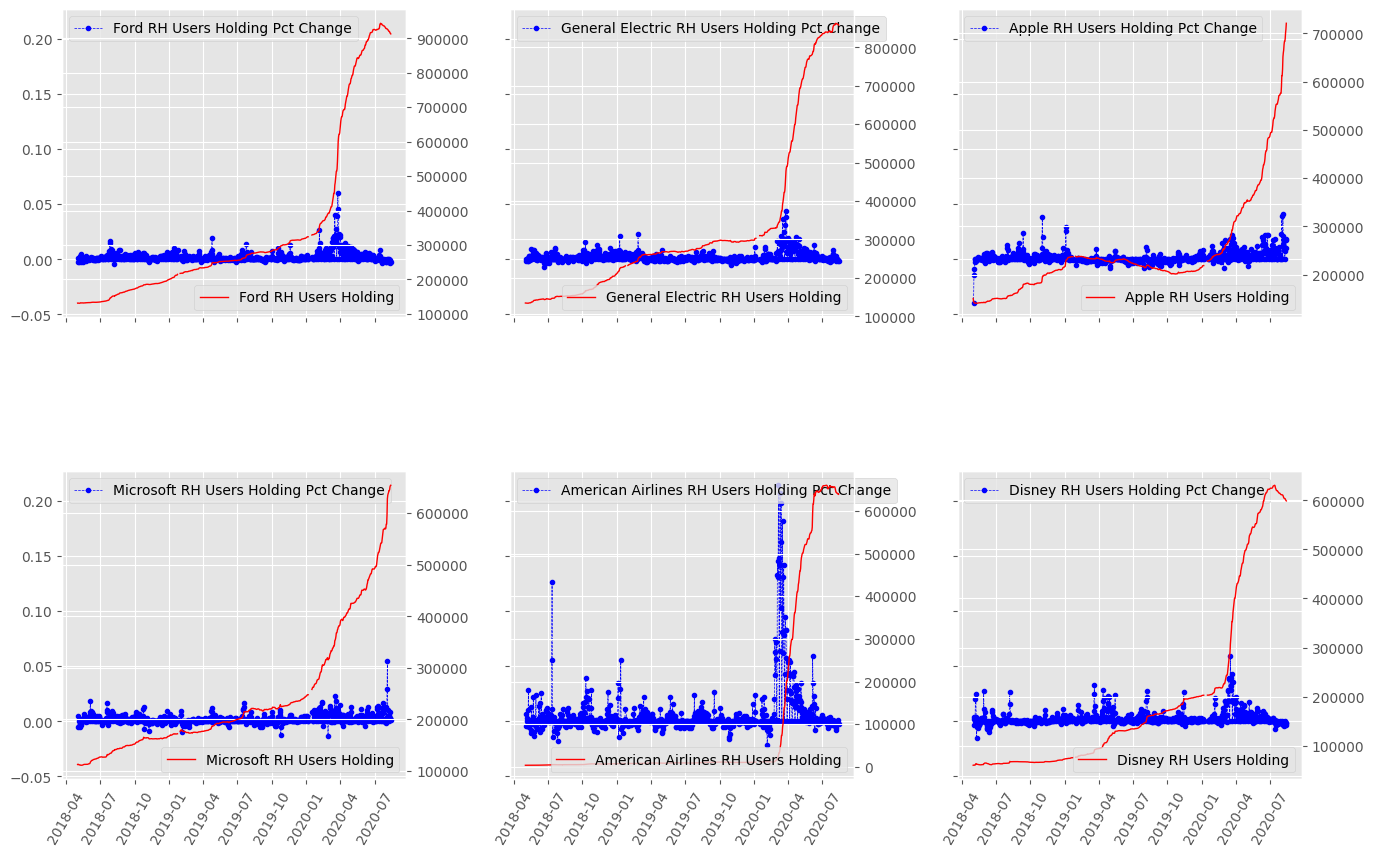

In [ ]:
import matplotlib.pyplot as plt

# Creating subplots
fig, axs = plt.subplots(nrows=2, ncols=3, figsize=(16, 10), sharex=True, sharey=True)
axs = axs.flatten()  # Flatten the 2D array of axes for easier iteration

# Sample stock data (replace these with your actual dataframes)
stocks = ['Ford', 'General Electric', 'Apple', 'Microsoft', 'American Airlines', 'Disney']
data_stocks = [data_ford, data_GE, data_Apple, data_Microsoft, data_American_Airlines, data_Disney]

# Calculate percentage change
pct_change_stocks = [data.pct_change(fill_method=None).dropna() for data in data_stocks]

# Loop through each stock to create plots
for j in range(len(stocks)):
    # Plot percentage change
    axs[j].plot(pct_change_stocks[j], label=stocks[j] + ' RH Users Holding Pct Change',
                color='blue', linestyle='--', marker='.', linewidth=0.5)
    axs[j].legend(loc='upper left')
    axs[j].tick_params(axis='x', rotation=60)

    # Create a second y-axis for the same subplot
    ax2 = axs[j].twinx()  # Instantiate a second axes that shares the same x-axis
    ax2.plot(data_stocks[j], label=stocks[j] + ' RH Users Holding',
             color='red', linestyle='-', linewidth=1)
    ax2.legend(loc='lower right')
    ax2.tick_params(axis='x', rotation=60)

# Adjust spacing between subplots
plt.subplots_adjust(wspace=0.3, hspace=0.5)  # Adjust as necessary for visibility
plt.show()

**Data Preparation with Yahoo Finance API**

In [ ]:
import datetime as dt  # Convert strings to datetime objects
import time
import yfinance as yf

# Initialize parameters
returns = []
tickers = ['F', 'GE', 'AAPL', 'MSFT', 'AAL', 'DIS']

# Convert dates to datetime objects
start_date = dt.datetime(2018, 4, 1)  # April 1, 2018
end_date = dt.datetime(2020, 8, 13)   # August 13, 2020

# Download data and calculate returns for each stock
for ticker in tickers:
    stock_data = yf.download(ticker, start_date, end_date)
    adj_close = stock_data[['Adj Close']]
    daily_returns = adj_close.pct_change()# Calculate daily returns
    daily_returns = daily_returns.rename(columns={'Adj Close': f'{ticker}_returns'})# Rename column to include ticker
    returns.append(daily_returns)

# Combine all returns into one dataframe
daily_returns_of_top_stocks = pd.concat(returns, axis=1)

# Convert index to date format
daily_returns_of_top_stocks.index = daily_returns_of_top_stocks.index.date

**Simple Stock Returns Analysis Visualization**

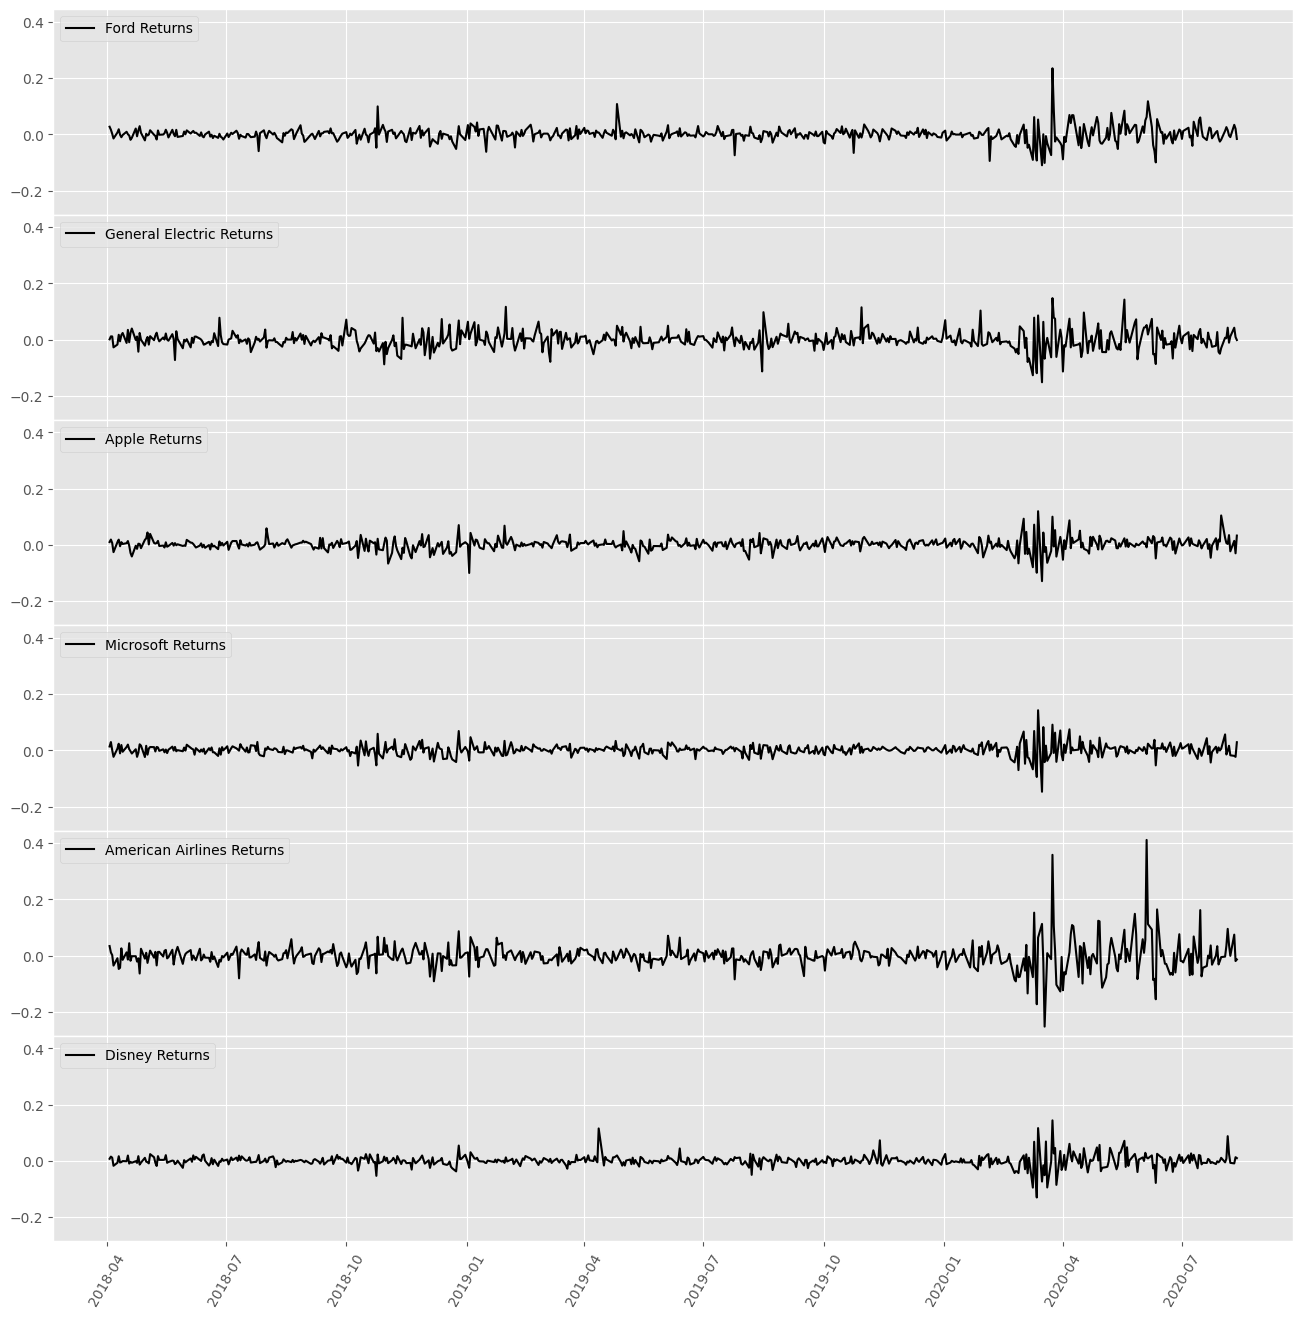

In [ ]:
# Create subplots for returns only
fig, axs = plt.subplots(nrows=6, ncols=1, figsize=(16,16), sharex=True, sharey=True)
axs = axs.flatten()

stocks = ['Ford', 'General Electric', 'Apple', 'Microsoft', 'American Airlines', 'Disney']

for j in range(len(stocks)):
    axs[j].plot(returns[j], label=stocks[j]+' Returns', color='black', linestyle='-')
    axs[j].legend(loc='upper left')
    axs[j].tick_params(axis='x', rotation=60)

plt.subplots_adjust(wspace=0, hspace=0)
plt.show()

**Combined Returns and Holdings Visualization**

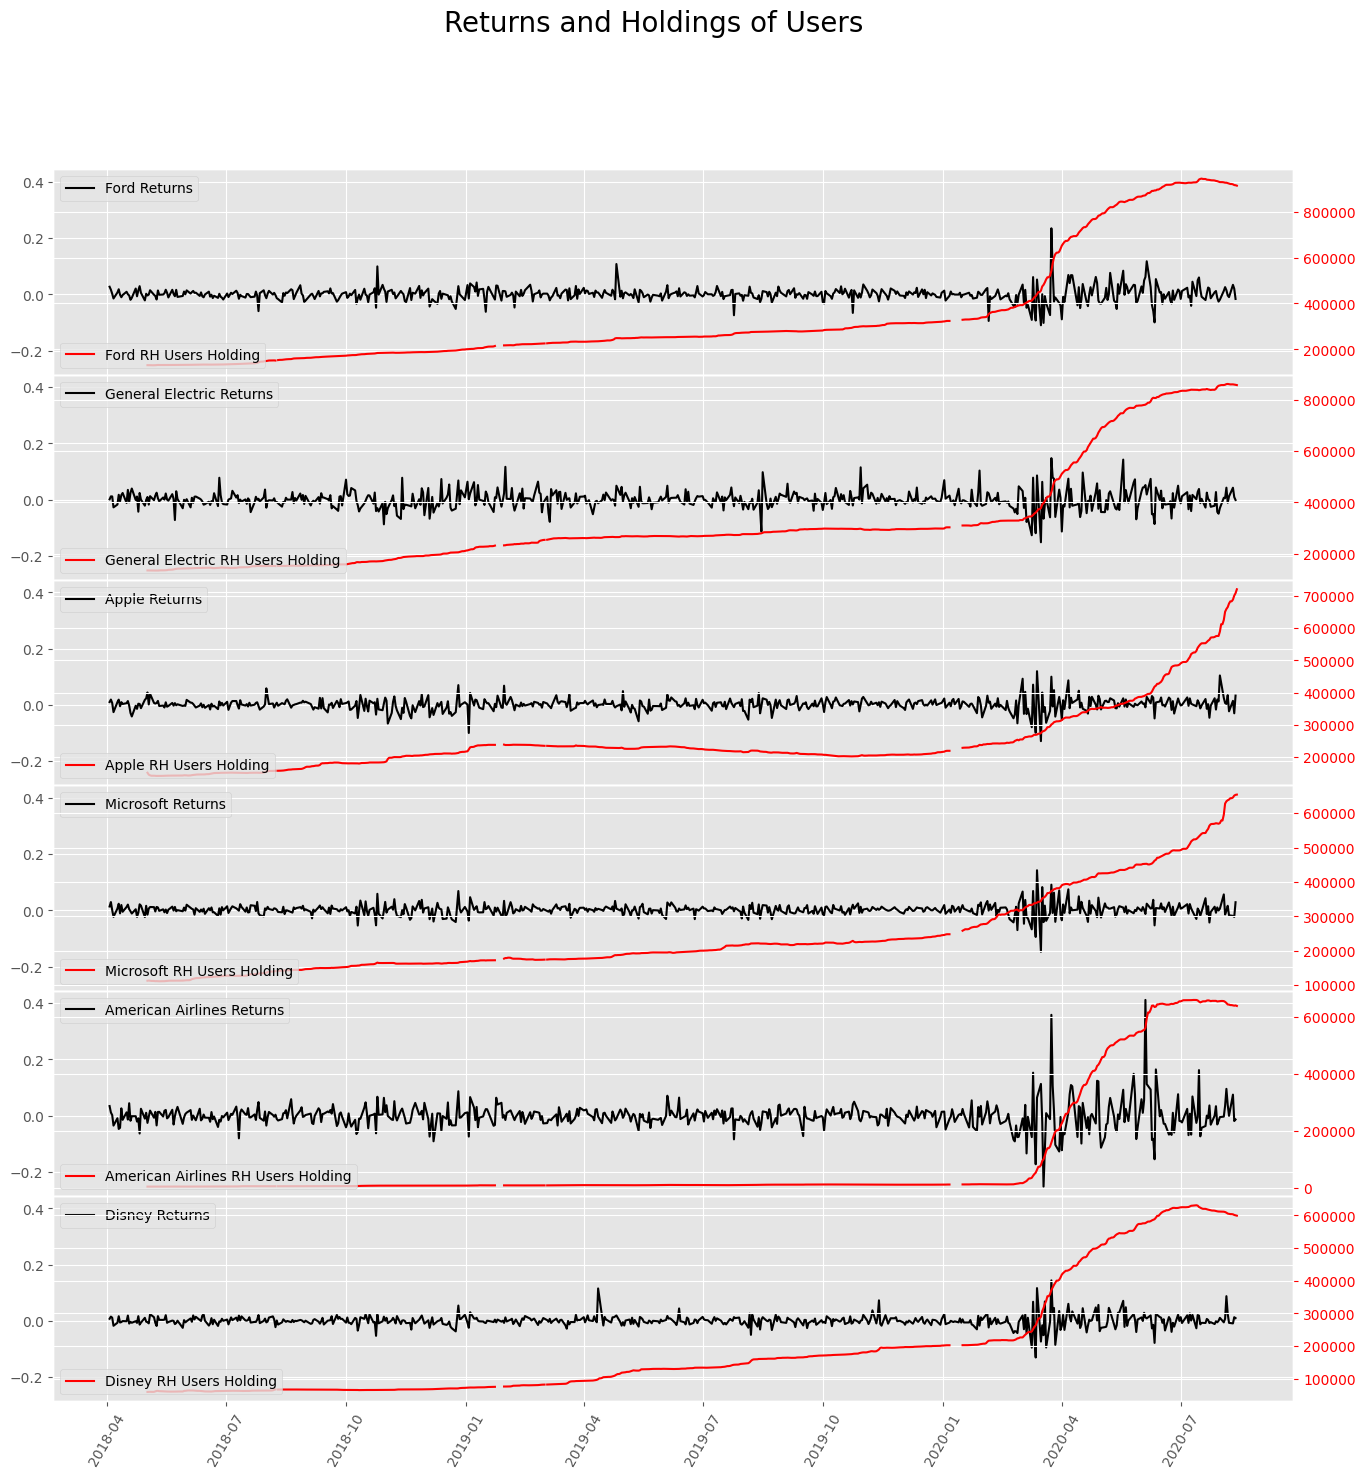

In [ ]:
# Create subplots with dual y-axes
fig, axs = plt.subplots(nrows=6, ncols=1, figsize=(16,16), sharex=True, sharey=True)
axs = axs.flatten()

stocks = ['Ford', 'General Electric', 'Apple', 'Microsoft', 'American Airlines', 'Disney']
data_stocks = [data_ford, data_GE, data_Apple, data_Microsoft, data_American_Airlines, data_Disney]

for j in range(len(stocks)):
    # Plot returns on primary y-axis
    axs[j].plot(returns[j], label=stocks[j]+' Returns', color='black', linestyle='-')
    axs[j].legend(loc='upper left')
    axs[j].tick_params(axis='x', rotation=60)

    # Plot holdings on secondary y-axis
    ax2 = axs[j].twinx()
    ax2.plot(data_stocks[j], label=stocks[j]+' RH Users Holding', color='red', linestyle='-')
    ax2.legend(loc='lower left')
    ax2.tick_params(axis='y', colors='red')

plt.subplots_adjust(wspace=0.3, hspace=0)
plt.suptitle('Returns and Holdings of Users', fontsize=20)
plt.show()

**Key Insights:**
- Significant changes in holdings during market events indicate reactive trading behavior.
- High-profile stocks (e.g., tech, meme stocks) consistently dominate holdings, reflecting social sentiment and media influence.

#**4. Conclusion**
- Retail investors are reactive to market volatility and high-profile events.
- Top traded stocks are often influenced by social sentiment and media.
- This analysis provides insights into how market events shape investor behavior.
